In [1]:
# # 📌 Box-Cox ve Yeo-Johnson Dönüşümleri

# ## 🎯 Ne İş Yaparlar?
# - **Çarpıklığı Düzeltir:** Sağa veya sola çarpık (skewed) sürekli değişkenleri çan eğrisine (normal/Gauss dağılımına) yaklaştırır.
# - **Model Basarımını Artırır:** Verinin normal dağıldığını varsayan lineer/lojistik regresyon, LDA vb. algoritmaların performansını ve katsayı kararlılığını iyileştirir.
# - **Varyansı Sabitler:** Aykırı değerlerin ve yüksek değişkenliğin olumsuz etkilerini yumuşatır.

# ---

# ## 💡 Ne Zaman ve Nereye Yazılır?
# - **Veri Ön İşleme (Preprocessing / Feature Engineering)** adımında uygulanır.
# - Sürekli (continuous) sayısal değişkenlerde çarpıklık (skewness) tespit edildiğinde tercih edilir.
# - Ağaç tabanlı modeller (Random Forest, XGBoost vb.) normallik aramadığı için genelde **lineer ve mesafe tabanlı modellerde** kullanılır.

# ---

# ## ⚡ Box-Cox vs Yeo-Johnson (Kritik Fark)
# | Yöntem | Desteklediği Veri | Kullanım Durumu |
# | :--- | :--- | :--- |
# | **Box-Cox** | Sadece **$x > 0$** (Kesinlikle Pozitif) | Veride 0 veya negatif değer yoksa |
# | **Yeo-Johnson** | **Tüm Sayılar** ($x > 0$, $x = 0$, $x < 0$) | Veride 0 veya negatif değerler varsa |

# > 📌 **İpucu:** `scikit-learn` içinde `PowerTransformer(method='box-cox')` veya `method='yeo-johnson'` olarak çağrılır.

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline 

In [3]:
df = pd.read_csv('23-boston.csv')

In [4]:
df.head()

,0.00632 18.00 2.310 0 0.5380 6.5750 65.20 4.0900 1 296.0 15.30 396.90 4.98 24.00
0,0.02731 0.00 7.070 0 0.4690 6.4210 78...
1,0.02729 0.00 7.070 0 0.4690 7.1850 61...
2,0.03237 0.00 2.180 0 0.4580 6.9980 45...
3,0.06905 0.00 2.180 0 0.4580 7.1470 54...
4,0.02985 0.00 2.180 0 0.4580 6.4300 58...


In [5]:
# suan da vermiz tek kolon seklinde gozukuyor data seti paylasan kisi gerekli kodlari altina birakmis 

In [6]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [7]:
df = pd.read_csv("23-boston.csv", header=None, delimiter=r"\s+", names=column_names)

In [8]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [9]:
df.shape

(506, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [11]:
# nan vermiz yok 

In [12]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [13]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [14]:
def plot_all_histograms(df):
    pass

In [15]:
num_cols = df.select_dtypes(include=[np.number]).columns 

In [16]:
num_cols

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [17]:
import math 
num_cols = df.select_dtypes(include=[np.number]).columns 
n_cols = 3
n_rows = math.ceil(len(num_cols)/n_cols) 

In [18]:
# Sayısal sütunların grafiklerini ekrana 3'erli sütunlar halinde düzenli çizebilmek için gerekli satır sayısını dinamik hesaplar.

In [19]:
n_rows

5

In [20]:
import math
def plot_all_histograms(df, title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize = (5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

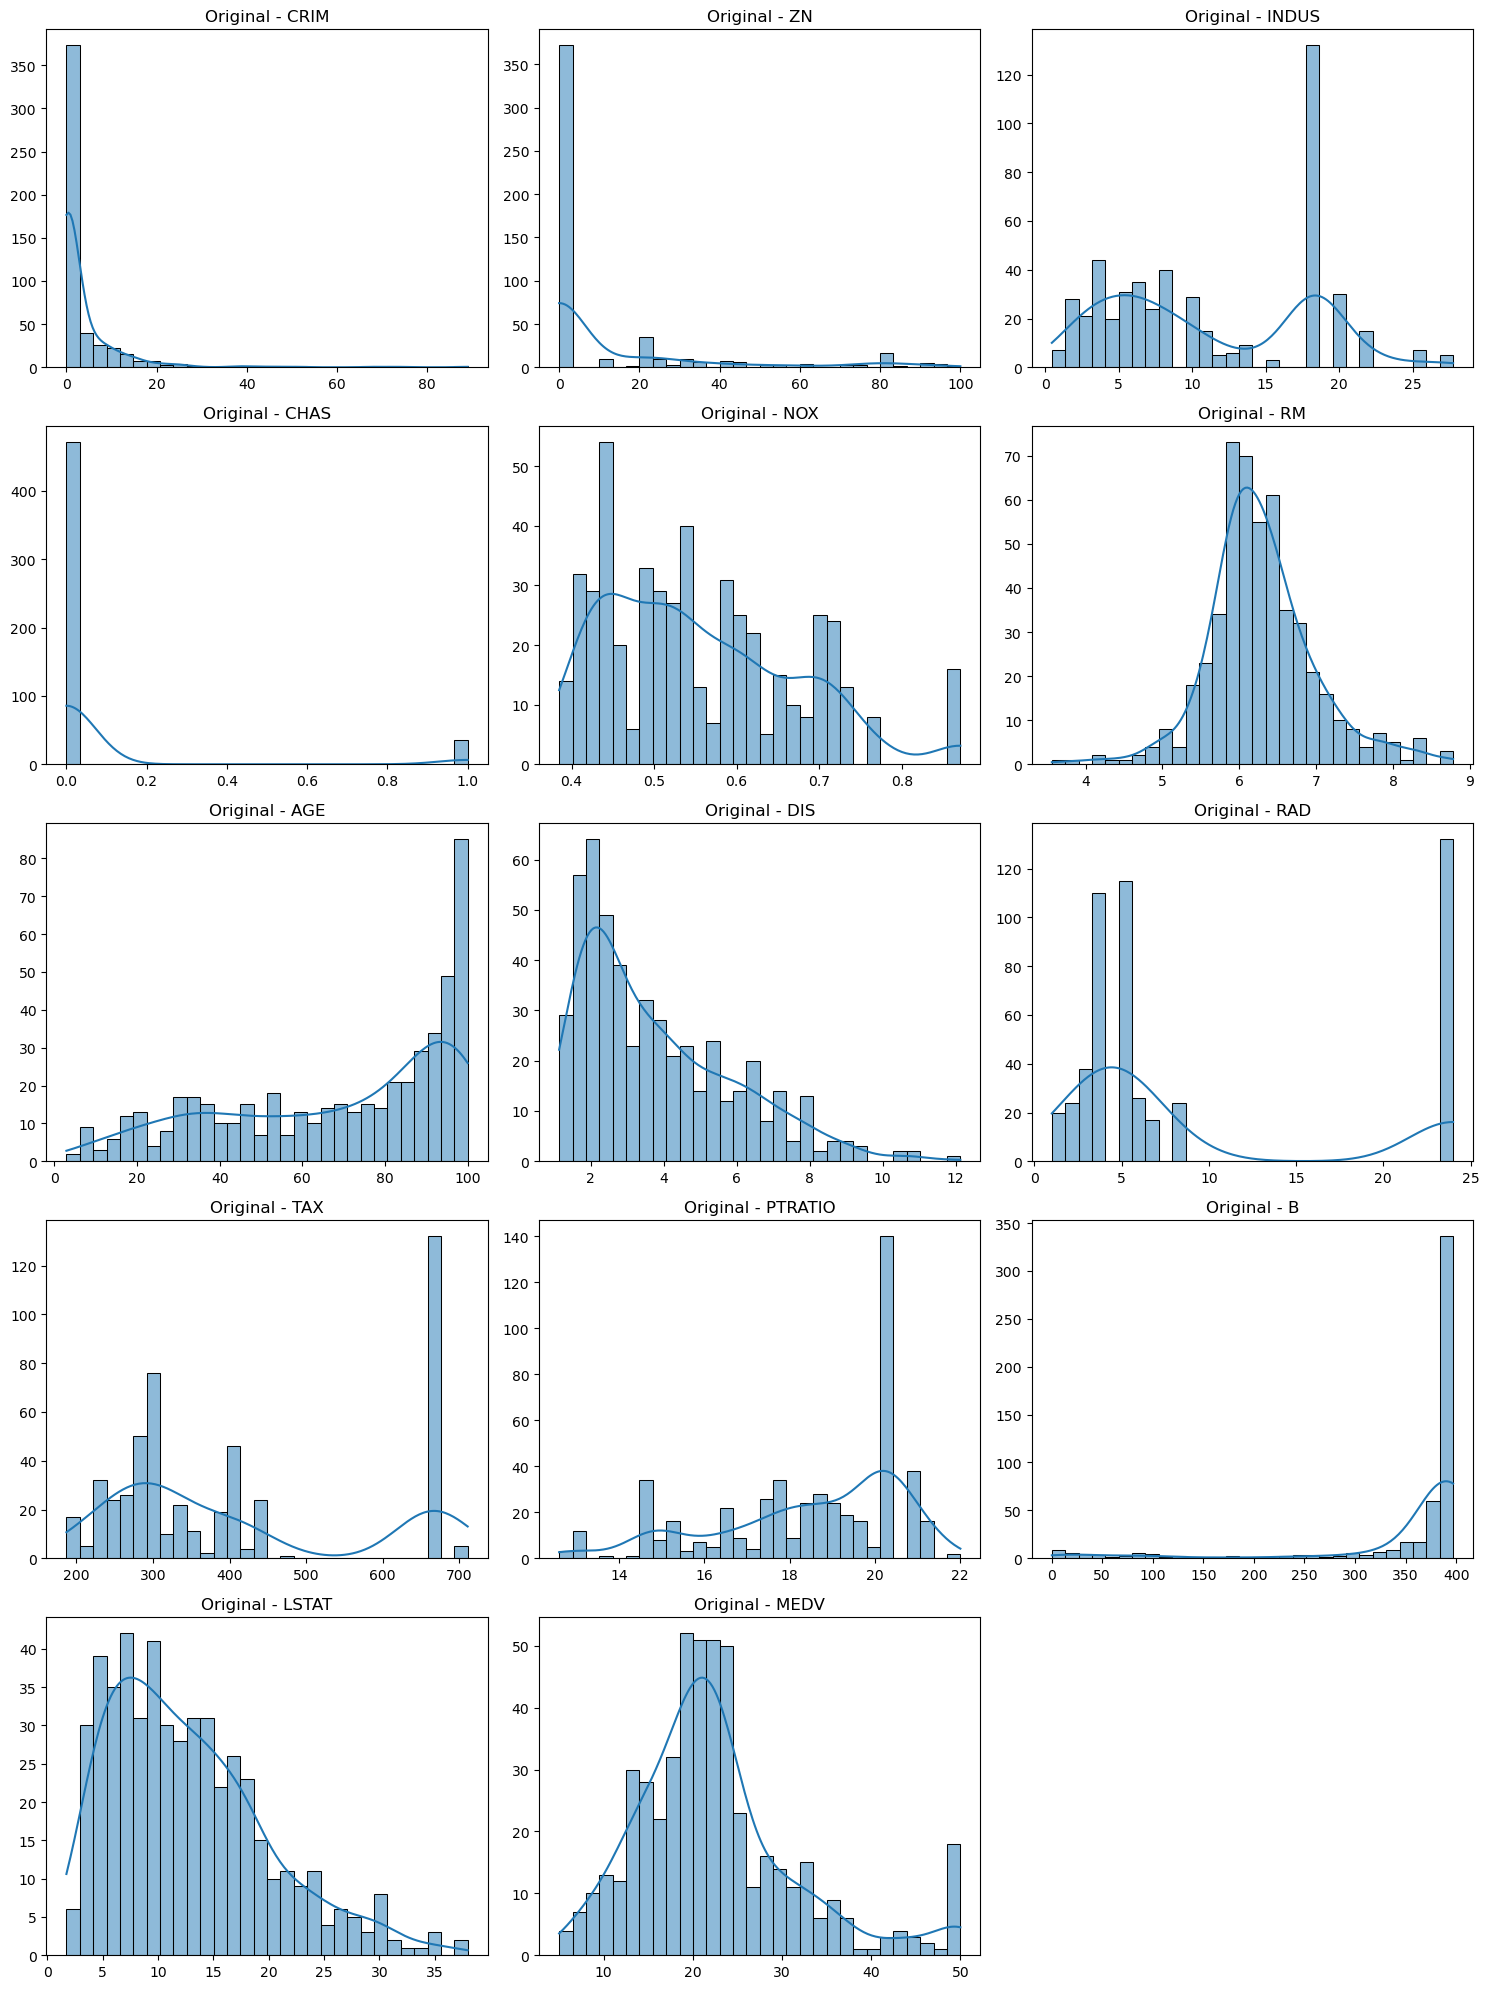

In [21]:
plot_all_histograms(df,title_prefix='Original -')

In [22]:
# # 📌 `plot_all_histograms` Fonksiyonu Özet

# ## 🎯 Ne İş Yapar?
# - **Otomatik Görselleştirme:** Verisetindeki tüm sayısal (int, float) değişkenleri otomatik tespit eder.
# - **Dinamik Izgara (Grid):** Değişken sayısına göre grafik alanının satır/sütun düzenini kendisi hesaplar.
# - **Dağılım Analizi:** Her değişken için hem çubuk grafik (histogram, `bins=30`) hem de yumuşatılmış yoğunluk eğrisi (`kde=True`) çizer.

# ---

# ## 💡 Nerede ve Ne Zaman Kullanılır?
# - **Keşifçi Veri Analizi (EDA):** Verisetini yükler yüklemez değişkenlerin **normal dağılıma** uyup uymadığını veya **çarpıklık (skewness)** durumunu incelemek için.
# - **Veri Dönüştürme Öncesi/Sonrası:** Box-Cox, Yeo-Johnson veya Log dönüşümü yapmadan önceki ve sonraki dağılım değişimlerini kıyaslamak için.
# - **Aykırı Değer / Varyans Kontrolü:** Verilerin hangi aralıklarda yoğunlaştığını hızlıca tespit etmek için.

In [23]:
from scipy.stats import skew 

In [24]:
df.apply(skew).sort_values(ascending=False)

CRIM       5.207652
CHAS       3.395799
ZN         2.219063
MEDV       1.104811
DIS        1.008779
RAD        1.001833
LSTAT      0.903771
NOX        0.727144
TAX        0.667968
RM         0.402415
INDUS      0.294146
AGE       -0.597186
PTRATIO   -0.799945
B         -2.881798
dtype: float64

In [25]:
# # 📌 `df.apply(skew).sort_values(ascending=False)`

# - **Ne Yapar:** Sütunların çarpıklığını (skewness) hesaplayıp büyükten küçüğe sıralar.
# - **Amacı:** Hangi sütunlara dönüşüm (transformation: Log, Box-Cox, Yeo-Johnson) uygulanacağını belirler.

# ## ⚡ Değer Yorumlama
# - **$\approx 0$:** Normal dağılım (Dönüşüm gerekmez)
# - **$> +0.5$:** Sağa çarpık (Dönüşüm adayı)
# - **$< -0.5$:** Sola çarpık (Dönüşüm adayı)

In [26]:
X = df.drop('MEDV',axis=1)
y = df['MEDV']

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [29]:
# X lermizi Yeojhonsan ile tranform edelim Y lermizi BoxCox ile tranform edelim hemde farki gormuz oluruz 

In [30]:
from sklearn.preprocessing import PowerTransformer

In [31]:
pt_X = PowerTransformer(method='yeo-johnson')

In [32]:
X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)  # fit DEĞİL, transform olmalı!

In [33]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
X_train_transformed_df = pd.DataFrame(X_train_transformed,columns = column_names )

In [34]:
# # 📌 Yeo-Johnson Dönüşümü (PowerTransformer)

# - **Amaç:** Bağımsız değişkenlerdeki (`X`) çarpıklığı giderip veriyi normal dağılıma yaklaştırmak.
# - **`fit_transform(X_train)`:** Train setinin istatistiklerini (lambda değerini) öğrenir ve dönüşümü uygular.
# - **`transform(X_test)`:** Test verisinde veri sızıntısını (data leakage) önlemek için train'den öğrenilen parametreleri kullanır.
# - **DataFrame Oluşturma:** Dönüşüm sonucu oluşan NumPy dizisini tekrar sütun isimleriyle Pandas DataFrame'ine çevirir.

In [35]:
X_train_transformed_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.904167,1.724429,-1.219281,-0.267615,-1.133724,0.654830,-1.320696,1.297076,-0.255374,0.244488,-1.427362,0.426553,-1.322242
1,1.605896,-0.588616,1.011100,-0.267615,1.465402,-0.490305,0.689192,-1.115580,1.457243,1.370436,0.848622,-2.703630,2.139134
2,-0.925383,-0.588616,-1.492987,-0.267615,-0.496175,-0.175553,-0.053289,0.037511,-0.944274,-1.975622,-0.502857,0.350835,0.303698
3,0.999995,-0.588616,1.161199,-0.267615,2.026049,-0.985039,0.975581,-1.456339,-0.255374,0.275674,-1.555351,-0.550002,1.209644
4,-0.628294,-0.588616,0.138417,-0.267615,-1.475942,-0.043701,-1.910821,0.936406,-0.551621,-0.473029,0.216963,0.073562,-0.622936
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,1.668295,-0.588616,1.011100,-0.267615,1.072096,1.447764,1.100495,-1.734661,1.457243,1.370436,0.848622,0.643031,0.342306
400,-0.390949,-0.588616,1.382524,-0.267615,0.752694,-0.654775,0.996311,-0.517389,-0.551621,0.472960,1.592342,0.396688,0.542831
401,1.366441,-0.588616,1.011100,-0.267615,1.206460,0.184264,1.021234,-1.275079,1.457243,1.370436,0.848622,0.643031,1.013945
402,-0.636275,1.664783,-0.676234,-0.267615,-1.216540,-0.973231,-0.000938,1.644135,0.171014,-0.249768,0.159469,0.409545,0.922866


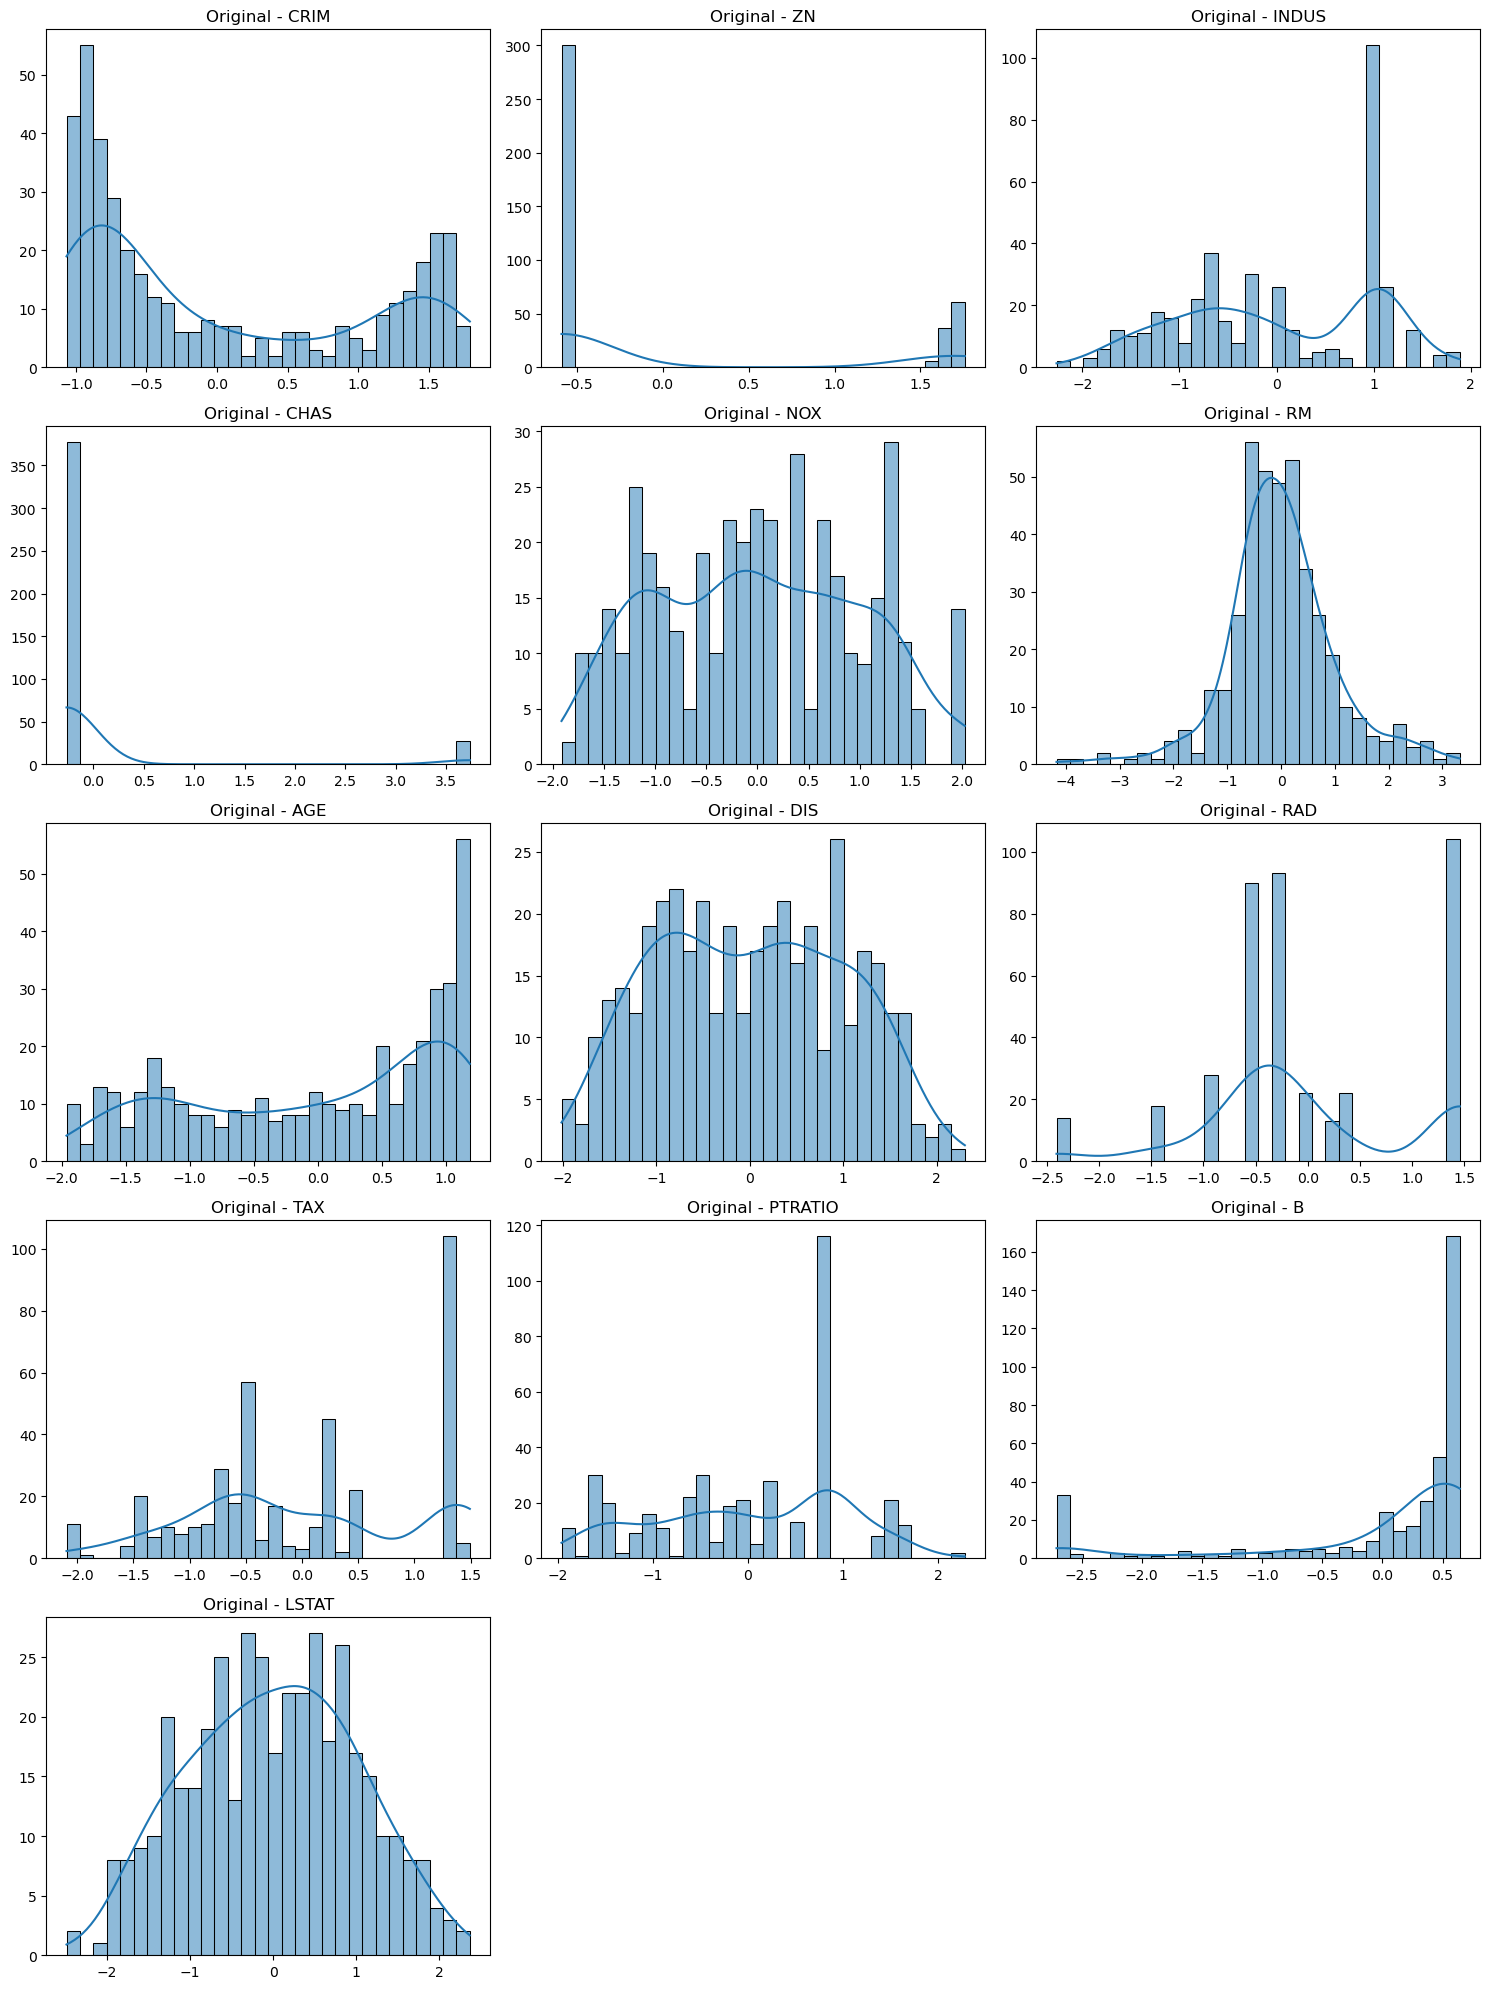

In [36]:
plot_all_histograms(X_train_transformed_df,title_prefix='Original -')

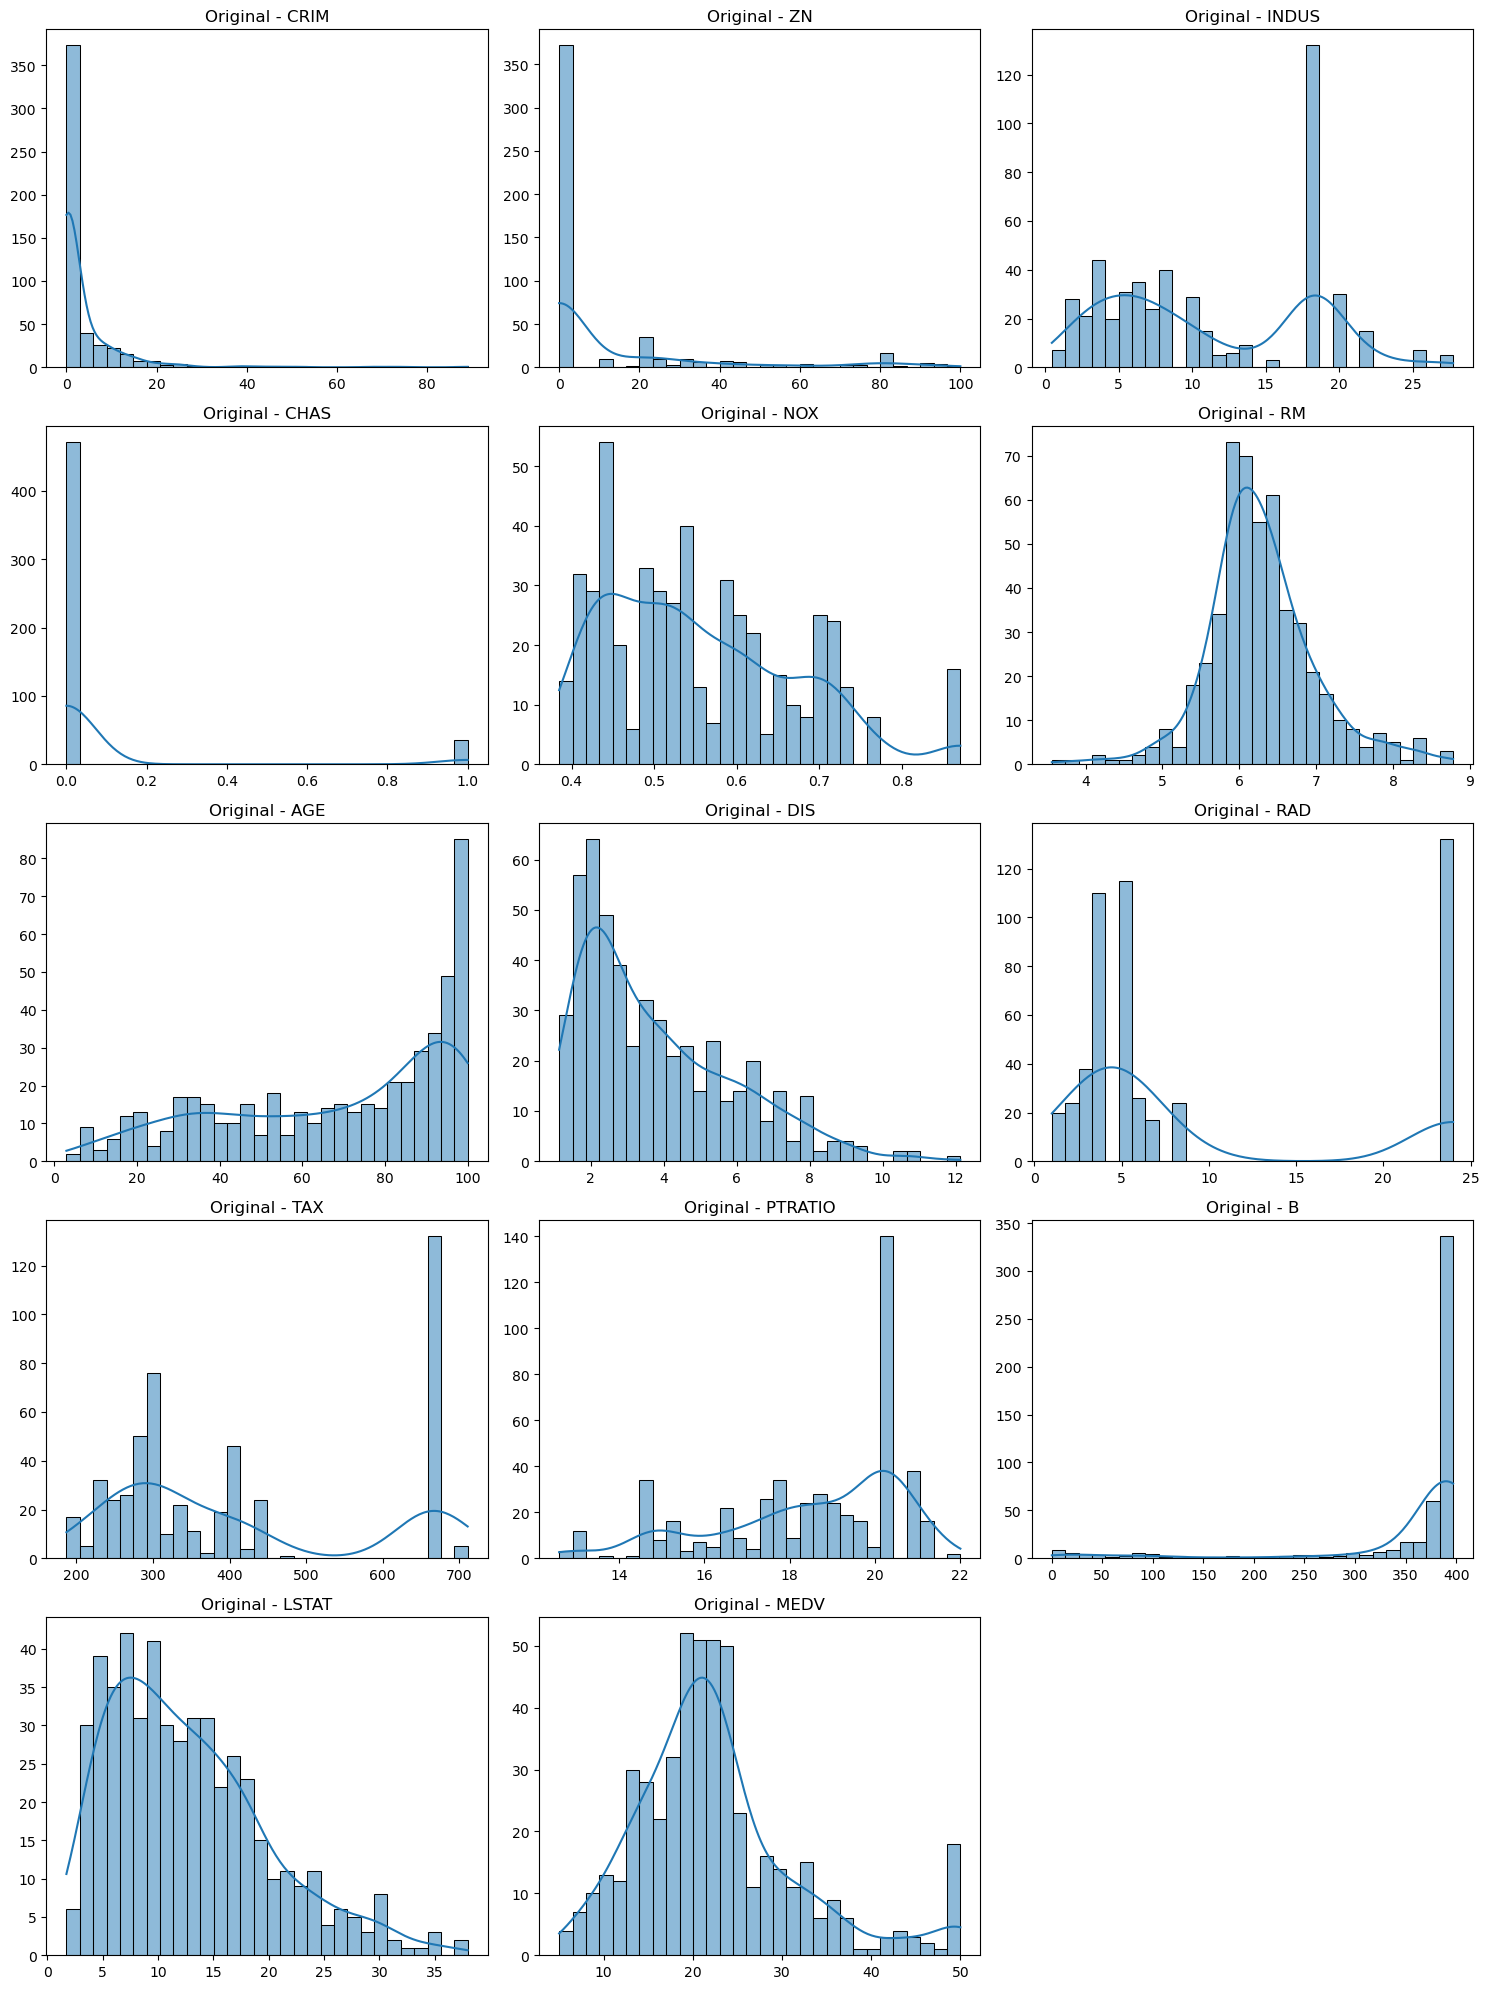

In [37]:
plot_all_histograms(df,title_prefix='Original -')

In [38]:
# eski yeni arasdinaki tablolarimiz baktigimizda bazi yerlerin normal dagiulima yaklastigini goruyoruz hepsinde ayni etkiyi yaratmaz zaten 

In [39]:
from scipy.stats import boxcox

In [40]:
boxcox(y_train)

(array([4.84566478, 2.6337955 , 4.7877742 , 3.60496591, 4.34497185,
        4.19030731, 4.21544245, 5.31802204, 4.77471725, 4.18186609,
        4.10442777, 5.8511485 , 4.24852567, 4.1218698 , 4.46754554,
        4.07800566, 3.15055966, 4.74838699, 4.41472178, 2.82185272,
        3.9028955 , 5.8511485 , 4.39940407, 3.15055966, 4.23204469,
        5.8511485 , 5.70646282, 4.38398352, 5.11031782, 4.09565525,
        3.85438551, 3.62690465, 3.37189121, 4.44505472, 5.19438693,
        4.36845856, 4.35282759, 4.3291788 , 4.30528212, 3.9783335 ,
        4.13917647, 4.56971198, 4.16488776, 4.06912797, 4.42993817,
        2.96306251, 4.69483551, 3.03730045, 4.01510096, 3.85438551,
        3.48002143, 4.58394834, 5.8511485 , 3.94093982, 4.37623419,
        4.91457817, 4.27302406, 4.64696352, 4.42234255, 4.15635011,
        5.22723362, 2.96306251, 4.68125649, 4.83292044, 5.00549881,
        4.39170675, 3.9783335 , 4.08684798, 3.33454579, 4.20709524,
        4.29726046, 3.6913874 , 4.88974588, 3.85

In [41]:
# Verideki çarpıklığı azaltıp normal dağılıma yaklaştırmak için Box-Cox dönüşümü uygular (sadece pozitif değerlerle çalışır).
# cok kisa bir surede bu kod sayesinde hallederiz 

In [42]:
y_train_transformed,lamda_y = boxcox(y_train)

In [43]:
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [44]:
# Box-Cox dönüşümü uygulanmış tahmin veya verileri orijinal ölçeğine ve gerçek değerlerine geri döndürmek (ters dönüşüm yapmak) için kullanılır.

In [45]:
from sklearn.linear_model import LinearRegression

In [46]:
model = LinearRegression()
model.fit(X_train_transformed,y_train_transformed)

LinearRegression()

In [47]:
y_pred_transformed = model.predict(X_test_transformed)

In [48]:
y_pred_original = inverse_boxcox(y_pred_transformed,lamda_y)

In [49]:
from sklearn.metrics import r2_score,mean_squared_error

In [52]:
print(r2_score(y_test,y_pred_original))
print(mean_squared_error(y_test,y_pred_original))

0.7755639716957539
17.35592799766205


In [53]:
# Box-Cox ile y'yi normale yaklaştırıp modeli eğittik, tahminleri inverse_boxcox ile orijinal ölçeğe çevirip R2 ve MSE ile değerlendirdik.

In [54]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [55]:
y_pred = model.predict(X_test)

In [57]:
print(r2_score(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

0.692074903865211
23.81224546508094


In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [60]:
df = pd.read_csv('24-medical_cost.csv')

In [61]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [65]:
# sex,smoker kismini 0 ve 1 e cevirmemiz gerecek ve region kismida kategorik oldugunu icin encoding yapmamaiz gerekecek 

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [63]:
df.isnull().sum()

Id          0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [64]:
df.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


In [66]:
# Feature engineriing 

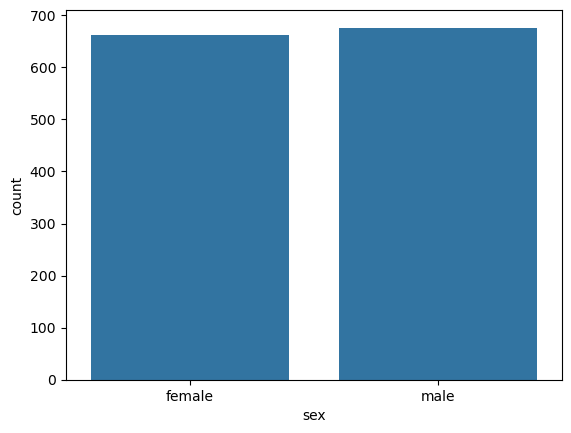

In [67]:
sns.countplot(data=df,x='sex')
plt.show()

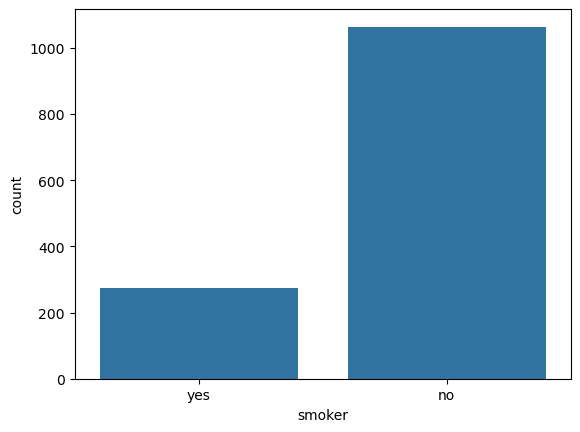

In [68]:
sns.countplot(data=df,x='smoker')
plt.show()

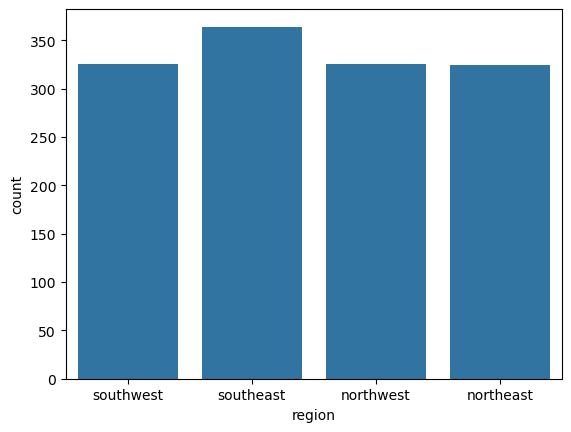

In [69]:
sns.countplot(data=df,x='region')
plt.show()

In [70]:
# value count ilede yapabiliridk ama bu daha guzel gozukuyor 

In [71]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


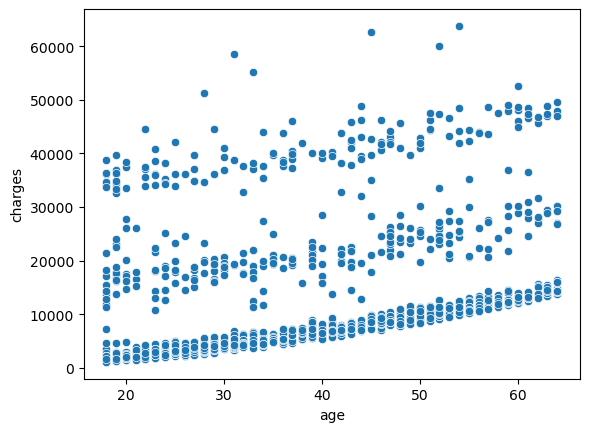

In [73]:
sns.scatterplot(data=df,x='age',y='charges')
plt.show()

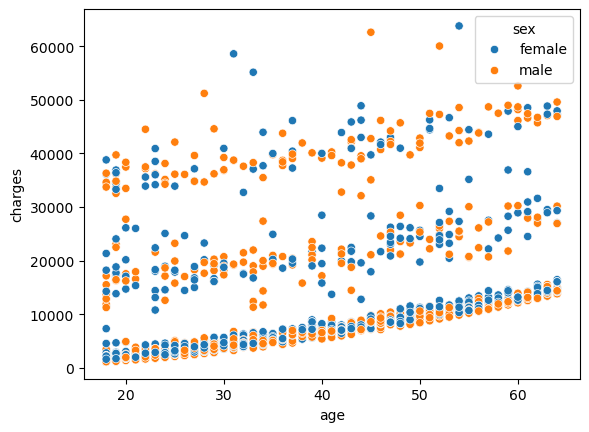

In [74]:
sns.scatterplot(data=df,x='age',y='charges',hue='sex')
plt.show()

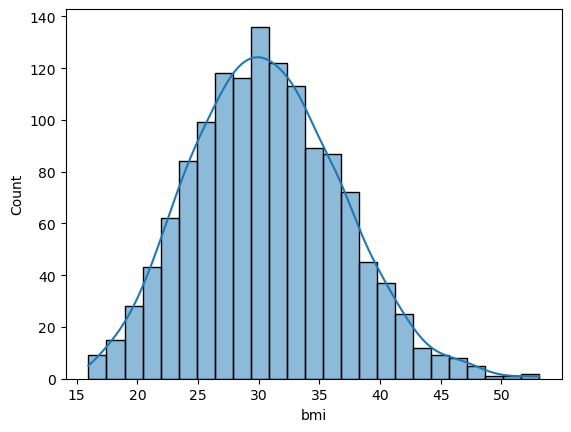

In [76]:
sns.histplot(data=df,x='bmi',kde=True)
plt.show()

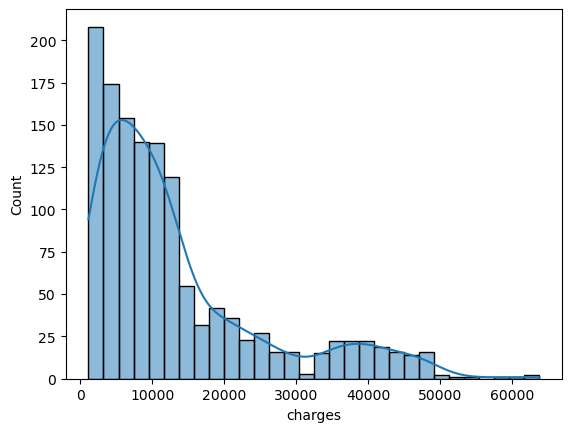

In [77]:
sns.histplot(data=df,x='charges',kde=True)
plt.show()

In [78]:
df.drop('Id',inplace=True,axis=1)

In [79]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [80]:
# id kolonumuzla alakali bir isimiz olmadigi icin bu kolonu silmeyi tercih ettim 

In [81]:
df['sex'] = df['sex'].map({'male':0,'famale':1})
df['smoker'] = df['smoker'].map({'no':0,'yes':1})

In [82]:
df['sex'].value_counts()

sex
0.0    676
Name: count, dtype: int64

In [83]:
df['smoker'].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [84]:
# 4 tane region vardi bu yuzden one hot encoding yapabiliriz 

In [85]:
X = df.drop('charges',axis=1)
y= df['charges']

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [88]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [89]:
categorical_cols = ["region"]

preprocessor = ColumnTransformer(transformers=
    [
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
    ], remainder= "passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [90]:
# Categorical (metin) sütunları One-Hot Encoding ile sayısala çevirip diğer sütunlara dokunmadan veri ön işlemeyi otomatikleştirir.

In [91]:
# categorical_cols: Dönüştürülecek metin sütunlarının listesi.
# ColumnTransformer: Farklı sütunlara ayrı ön işleme adımları uygulamayı sağlar.
# OneHotEncoder: Kategorik verileri 0 ve 1 içeren sayısal kolonlara çevirir.
# drop="first": Çoklu doğrusallığı (dummy variable trap) önlemek için ilk kategoriyi atar.
# handle_unknown="ignore": Test verisinde yeni/bilinmeyen kategori gelirse hata vermez.
# remainder="passthrough": İşlem görmeyen sayısal sütunları veri setinde korur.
# fit_transform(X_train): Train verisinde kategorileri öğrenir ve dönüştürür.
# transform(X_test): Test verisini, Train'de öğrenilen kurallara göre dönüştürür.

In [93]:
from lightgbm import  LGBMRegressor

In [96]:
model = LGBMRegressor(verbose=-1, n_jobs=1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [97]:
from sklearn.metrics import r2_score,mean_squared_error

In [98]:
print(r2_score(y_pred,y_test))
print(mean_squared_error(y_pred,y_test ))

0.8636669836215215
18458085.613847945


In [100]:
# HYPERPARAMETER TUNING 

In [101]:
param_grid = {
    "num_leaves" : [31, 50, 70],
    "max_depth" : [-1, 5, 10],
    "learning_rate" : [0.01, 0.05, 0.1],
    "n_estimators" : [100, 300, 1000],
    "min_child_samples" : [10, 20, 30],
    "subsample" : [0.6, 0.8, 1.0],
    "colsample_bytree" : [0.6, 0.8, 1.0],
    "reg_alpha" : [0, 0.5, 1.0],
    "reg_lambda" : [0, 0.5, 1.0]
}

In [102]:
from sklearn.model_selection import RandomizedSearchCV

In [103]:
import warnings
warnings.filterwarnings('ignore')

In [104]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs = -1
)

In [105]:
random_search.fit(X_train,y_train)

RandomizedSearchCV(cv=5, estimator=LGBMRegressor(verbosity=-1), n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [-1, 5, 10],
                                        'min_child_samples': [10, 20, 30],
                                        'n_estimators': [100, 300, 1000],
                                        'num_leaves': [31, 50, 70],
                                        'reg_alpha': [0, 0.5, 1.0],
                                        'reg_lambda': [0, 0.5, 1.0],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=15, scoring='neg_root_mean_squared_error')

In [106]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 100,
 'min_child_samples': 30,
 'max_depth': -1,
 'learning_rate': 0.1,
 'colsample_bytree': 0.8}

In [107]:
y_pred = random_search.predict(X_test)

In [108]:
print(r2_score(y_pred,y_test))
print(mean_squared_error(y_pred,y_test))

0.8775521864086795
16446549.93278381


In [109]:
# # onemli kisa bilgiler 

# transformatin herzmaan x ya y ye yapicaz diye bir sart yoktur
# y de normal dagilima uygun olmasi bizim icin cok onemlidir 

In [110]:
# Transformation (dönüşüm) her değişkene zorunlu değildir; ancak özellikle Lineer Regresyon modellerinde hedef değişkenin (y) normal dağılması model başarısı için kritik önem taşır.

In [111]:
# transformation uygulsaydik daha iyi olurmuydu ona bakicaz simdi de

In [112]:
from scipy.stats import boxcox

In [119]:
y_train_transformed , lambda_y = boxcox(y_train)

In [120]:
model = LGBMRegressor()
model.fit(X_train,y_train_transformed)

LGBMRegressor()

In [129]:
y_pred_transformed = model.predict(X_test)

In [130]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

In [ ]:
# Box-Cox ile değiştirilmiş tahminleri (y_pred_transformed) matematiksel ters formülle tekrar gerçek para/birim ölçeğine (y_pred_original) çevirir.
# Hedef değişkene (y) Box-Cox dönüşümü uyguladığın tüm regresyon projelerinde (ev fiyatı, maaş, harcama, sigorta masrafı tahmini vb.) 
## model tahminlerini aldıkran hemen sonra kopyalayıp yapıştırılır.

In [131]:
y_pred_original = inverse_boxcox(y_pred_transformed,lambda_y)

In [133]:
print(r2_score(y_pred_original,y_test))
print(mean_squared_error(y_pred_original,y_test))

0.8895535054323228
15470028.378876308


In [134]:
# tranfromed versiyonuz hyperparameter tuning den daha iyi bir sonuc verdi bize 

In [135]:
# TEKRAR 

In [136]:
# NE ZAMAN VE NERELERDE TRANSFORMATION (DÖNÜŞÜM) YAPILMALI?

# 1. HEDEF DEĞİŞKENDE (y) DÖNÜŞÜM:
# - Veri sağa veya sola aşırı çarpıksa (Skewed) ve sürekli pozitif sayılardan oluşuyorsa (ev fiyatı, maaş, sigorta masrafı vb.).
# - Özellikle Lineer Regresyon gibi parametrik modellerde y'nin normal dağılıma uyması model başarısını artırır.
# - Ağaç tabanlı modellerde (LightGBM, XGBoost, Random Forest) y'yi dönüştürmek her zaman şart değildir ama çoğu zaman hataları (MSE/RMSE) düşürür.

# 2. GİRDİ DEĞİŞKENLERİNDE (X) DÖNÜŞÜM:
# - Lineer/Lojistik Regresyon, KNN, SVM, Yapay Sinir Ağları (ANN) kullanırken tüm X sayısal değişkenleri ölçeklendirilmelidir (Scaling / Transformation).
# - Ağaç tabanlı modeller (LightGBM, XGBoost, Decision Tree) X değişkenlerinin ölçeğinden ve dağılımından etkilenmediği için X'e dönüşüm yapmak zorunlu değildir.

# ÖZET BURALARDA YAPILIR:
# Continuous (sürekli) + Pozitif Değerler + Çarpık Dağılım -> Box-Cox veya Log Transformation uygulanır.